# 5. Photometry

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib inline

# To interact with the plot use
# %matplotlib notebook

### Imports

In [38]:
import os
import h5py
import random
import numpy as np
import matplotlib.pyplot as plt

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot as pt
import platosim.photometryfile as phot
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
# from platosim.matplotlibrc import setup
# setup()

ModuleNotFoundError: No module named 'shapely'

---
## Illustration of default catalogue
---

I'm only showing some relevant fields of the inputfgs.yaml file. We want to simulate a little more than 1 week of continuous observations with a nominal camera.

In [3]:
# Inputs
inputDir    = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
inputFile   = inputDir + "/inputfile.yaml"

# Outputs
outputDir      = os.getcwd()
outputFileName = "output_example1"
starcatFile    = outputDir + "/starcat_example1.txt"

In [7]:
# Set up a Simulation object
sim = Simulation(outputFileName, inputFile, outputDir=outputDir)

# Run the simulation
simfile = sim.run(removeOutputFile=True)

In principle, you can continue from simFile and continue exploiting its contents. In this example, we will split up the post-processing for the sake of clarity. Let's show the subfield.

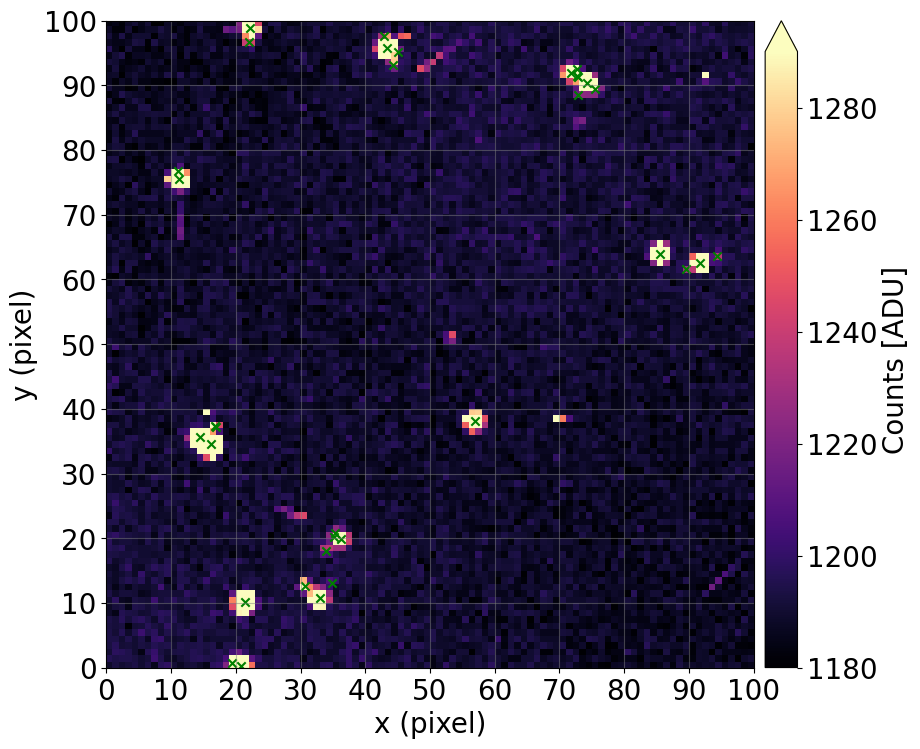

In [5]:
imageNr = 0
fig = f.showImage(imageNr, clipPercentile=1, imgScale="clip", 
                  figsize=(10,10), fontSize=20, useTitle=False,
                  showStarPositions=True, showStarIDs=False,
                  colorMap="magma", colorBar=True, showGrid=True) 

In [8]:
starID, row, col, Xmm, Ymm, flux = simfile.getStarCoordinates(0)
starID

array([ 41579,  41663,  41712,  41871,  41889,  41932,  41994,  42012,
        42201,  42287,  42477,  42537, 290555, 290782, 290903, 290904,
       290905, 291357, 291474, 291475, 291476, 291604, 291605, 291657,
       291658, 291659, 292418, 292419, 292420, 292421, 292422, 292423,
       293168, 293169], dtype=uint32)

---
## Create your own catalogue
---

In [9]:
# Set up a Simulation object
sim = Simulation(outputFileName, inputFile)
sim.outputDir = os.getcwd()

In [17]:
# Set the simulation parameters

sim["ObservingParameters/NumExposures"]           = 1000
sim["ObservingParameters/RApointing"]             = 180.0 
sim["ObservingParameters/DecPointing"]            = -70.0

sim["Sky/IncludeVariableSources"]                 = "no"
sim["Sky/VariableSourceList"]                     = "myVariableStar.txt"
sim["Sky/IncludeCosmicsInSubField"]               = "yes"
sim["Sky/IncludeCosmicsInSmearingMap"]            = "yes"
sim["Sky/IncludeCosmicsInBiasMap"]                = "yes"   

sim["Platform/UseJitter"]                         = "yes"
sim["Platform/JitterSource"]                      = "FromRedNoise"

sim["Telescope/GroupID"]                          = 1
sim["Telescope/UseDrift"]                         = "no"

sim["Camera/IncludeFieldDistortion"]              = "yes"

sim["PSF/Model"]                                  = "AnalyticNonGaussian"

sim["CCD/Position"]                               = 3
sim["CCD/IncludeConvolution"]                     = "no"

sim["SubField/ZeroPointRow"]                      = 2000
sim["SubField/ZeroPointColumn"]                   = 2000
sim["SubField/NumRows"]                           = 100
sim["SubField/NumColumns"]                        = 100

sim["Photometry/IncludePhotometry"]               = "yes"

In [18]:
# Specify the pixel coordinates of the subfield (not CCD) of the stars

# Two stars, equal magnitudes, separations of 0.5, 1, 3, and 4 pixels.
col = [ 4.1,  4.6, 14.3, 15.3, 24.5, 27.5, 36.0, 42.0]
row = [ 4.1,  4.1,  4.3,  4.3,  4.7,  4.7,  4.5,  4.5]
mag = [12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0]
starID = [100, 101, 102, 103, 104, 105, 106, 107]

# Two stars, mag diff of 4.0, separations of 0.5, 1, 3, and 4 pixels.
col = col + [ 6.1,  6.6, 16.3, 17.3, 26.5, 29.5, 38.0, 44.0]
row = row + [20.1, 20.1, 20.3, 20.3, 20.7, 20.7, 20.5, 20.5]
mag = mag + [ 9.0, 13.0,  9.0, 13.0,  9.0, 13.0,  9.0, 13.0]
starID = starID + [108, 109, 110, 111, 112, 113, 114, 115]

# Two stars, mag diff of 7.0, separations of 0.5, 1, 3, and 4 pixels.
col = col + [ 8.1,  8.6, 18.3, 19.3, 28.5, 31.5, 40.0, 46.0]
row = row + [41.1, 41.1, 41.3, 41.3, 41.7, 41.7, 41.5, 41.5]
mag = mag + [ 8.0, 15.0,  8.0, 15.0,  8.0, 15.0,  8.0, 15.0]
starID = starID + [116, 117, 118, 119, 120, 121, 122, 123]

# Convert from subfield to CCD pixel coordinates
row = np.array(row) + sim["SubField/ZeroPointRow"] 
col = np.array(col) + sim["SubField/ZeroPointColumn"] 
mag = np.array(mag)

# Create the star catalog file: an ascii file will be written with the columns
# ra, dec, and magnitude.
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

In [29]:
# Let's say we want photometry for star 100, we can create a photometry list using
photometryFile = os.getcwd() + "/photometry.txt"
sim.createPhotometryTargetFile(100, photometryFile)

In [31]:
# Run the simulation
simfile = sim.run(removeOutputFile=True)


2022-10-21 15:58:23 WARNING Camera: No point-like ghost positions to write to HDF5 file.



In [32]:
# We fetch the class that handles photometric time series
outfile = f"{outputDir}/{outputFileName}.hdf5"
lc = phot.PhotometryFile(outfile)

In [35]:
# Get light curve for requested star
time, fin, fout, mask = lc.getPhotometricTimeSeries(100)

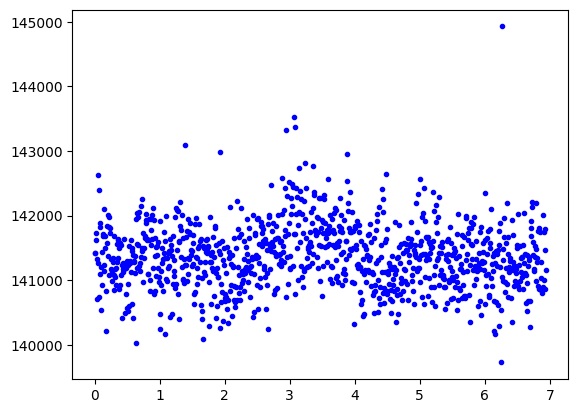

In [41]:
plt.figure()
# plt.plot(time, fin, 'r*')
plt.plot(time/3600, fout, 'b.');

# Work in progress below..

---
## Plot the positions of stars brighter than V=13 on top
---

Find out which stars bright

In [ ]:
allStarIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simfile.getStarCatalog()
brightStarIDs = allStarIDs[Vmag < 13.0]
print(f"Number of bright stars: {len(brightStarIDs)}")

Get all starIDs that are on image nr. 0. Note that these IDs are not necessarily the same as 'allStarIDs'. The latter contains all stars that have been detected, even if only in a few images because the star jittered in the subfield.

In [ ]:
starIDsInImage0, row, col, Xmm, Ymm, flux = simfile.getStarCoordinates(0)

Get the array indices of the bright stars in the 'starIDsInImage0' array. This requires a numpy trick.

In [ ]:
brightStarIndices = np.arange(len(starIDsInImage0))[np.in1d(starIDsInImage0, brightStarIDs)]

Now we can extract the row and column values of the bright stars:

In [ ]:
rowBrightStars = row[brightStarIndices]
colBrightStars = col[brightStarIndices]

Over-plot these row and column coordinates 

In [ ]:
plt.pcolormesh(image, cmap=cm.jet)
plt.scatter(floor(colBrightStars)+0.5, floor(rowBrightStars)+0.5, marker='x', c='lightgreen')
plt.xlim(0,100)
plt.ylim(0,100)

## Weighted photometry

We assume that each pixel value $f_{ij}$ is composed of a signal $s_{ij}$, a background $b_{ij}$, and noise $\epsilon_{ij}$:  

$$ f_{ij} = s_{ij} + b_{ij} + \varepsilon_{ij}$$

The background $b_{ij}$ is assumed to be known (in practice: read from the HDF5 file), and subtracted first. The total flux of a star is then computed using a weighted sum:

$$ F \equiv \sum\limits_{ij} \alpha \ w_{ij} (f_{ij} - b_{ij}) $$

where the weights are exponentially decaying:

$$w_{ij} = \exp\left(-\frac{(i-i_0)^2 + (j-j_0)^2}{2\sigma^2_{psf}}\right)$$

The exact (fractional) pixel coordinates $(i_0, j_0)$ of the star will be known using the Gaia catalog. For now, they are assumed to be known (i.e. read from the HDF5 file) as well.

## Figure out the width of the PSF

In [ ]:
outputFile = h5py.File("photometrySimulation.hdf5")

In [ ]:
psf = array(outputFile["/PSF/rebinnedPSFsubPixel"])
NsubPixels = outputFile["/InputParameters/SubField"].attrs["SubPixels"]
Npixels = int(psf.shape[0]/NsubPixels)
print("PSF consists of {0}x{0} pixels, with each pixel made up of {1}x{1} subpixels".format(Npixels, NsubPixels))

Plot the PSF to see what we're dealing with.

In [ ]:
plt.pcolormesh(psf, cmap=cm.nipy_spectral, vmax=0.01)                         # 'vmax' to get a prettier image
plt.grid(True, which='major', axis='both', linestyle='-', color='w')     # To get a 'pixel-grid' on top of it.
plt.xticks(arange(0, psf.shape[0], NsubPixels))
plt.yticks(arange(0, psf.shape[1], NsubPixels))
plt.xlim(0, psf.shape[0])
plt.ylim(0, psf.shape[1])

In [ ]:
sigmaPSF = phot.computePSFsigma(psf, NsubPixels, 500)
print("Standard deviation of the PSF (assuming symmetry): {0}".format(sigmaPSF))

The following function extracts the flux of all stars in every image in the HDF5 simulation output file, and writes the results to a second HDF5 file. Depending on the number of exposures, this can take a while.

In [ ]:
print(outputFile["Flatfield"])

In [ ]:
reload(phot)
print("Start")
phot.photometry("photometrySimulation.hdf5", "photometryOutput.hdf5",starIDsInImage0, maxNexposures=1000)
print("Done")

What did the photometry script do?
- Estimate the bias and subtract it
- Correct for open shutter smearing using the smearing maps
- Convert from [ADU] to [electrons] using the (FEE and CCD) gain
- Correct for the flatfield
- Subtract the background (assumed to be known)
- Do the weighted mask photometry, assuming the correct star positions

In [ ]:
%ls -lh photometryOutput.hdf5

### What does a photometry output HDF5 file look like?

In [ ]:
photFile = h5py.File("photometryOutput.hdf5")

In [ ]:
for group in photFile["/"]:
    print(group)

In [ ]:
for group in photFile["/Photometry"]:
    print(group)

In [ ]:
for dataset in photFile["/Photometry/Exposure000000"]:
    print(dataset)

Get the photometry done on the very first image. Fluxes are expressed in [electrons/exposure]

In [ ]:
starID           = array(photFile["/Photometry/Exposure000000/starID"])
inputFlux        = array(photFile["/Photometry/Exposure000000/trueFlux"])
estimatedFlux    = array(photFile["/Photometry/Exposure000000/estimatedFlux"])
varEstimatedFlux = array(photFile["/Photometry/Exposure000000/varFlux"])
Vmag             = array(photFile["/Photometry/Exposure000000/Vmag"])
NSR              = array(photFile["/Photometry/Exposure000000/NSR"])
maskSize         = array(photFile["/Photometry/Exposure000000/maskSize"]) 

The theoretical photon noise limit is not saved in HDF5 but is easily computable using the 'inputFlux'. If we sort the photon noise value, we can plot them in one smooth line. Note the 'inputFlux' stored in the HDF5 file is an electron flux, already taking into account the transmission efficiency, and the QE. 

In [ ]:
photonLimit = inputFlux/sqrt(inputFlux)
sorted = argsort(photonLimit)[::-1]

Plot the Signal-to-Noise ratio (per exposure) of all stars in the subfield, together with theoretical photon noise limit.

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.scatter(Vmag, 1.0 / NSR)
# plt.scatter(Vmag, SNR)
plt.plot(Vmag[sorted], photonLimit[sorted], c="r")
plt.grid(True, which='major', axis='both', linestyle='-', color='gray')
plt.xlabel("V magnitude")
plt.ylabel("S/N")
# plt.xlim(7,15)
# plt.ylim(0,1600)

The large S/N values at the faint end are caused by nearby brighter stars that significantly contaminate the flux level. Even for lower magnitudes, the S/N ratio is well below the photon noise limit because of the weighted photometry gives a lower weight to the tails of the PSF. You can of course play with the PSF-width you feed to phot.photometr(), to verify if it gives better results. For the very brightest stars, the electrons flowing away due to blooming are not recovered when extracting the stellar flux.

## Extract the time series of one particular star

We choose one particular 11th magnitude star

In [ ]:
print(Vmag)
print(starID)
plt.plot(starID, Vmag, 'k+')
print(Vmag[Vmag==11.0])

In [ ]:
myStarID = 15553#9789

In [ ]:
time, trueRow, trueCol, trueFlux, outputFlux = phot.getPhotometryTimeSeries("photometryOutput.hdf5", myStarID)

In [ ]:
flux = outputFlux

Convert the absolute flux [electrons/exposure] into a relative flux [ppm]

In [ ]:
relativeFlux = (flux - flux.mean())/flux.mean()*1.e6 

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.plot(time, flux)
plt.xlabel("Time")
plt.ylabel("Flux [e-/exp]")

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.plot(time, relativeFlux)
plt.xlabel("Time")
plt.ylabel("Relative flux [ppm]")

## Generate stellar granulation

In [ ]:
time =  array(outputFile["/StarPositions/Time"])

In [ ]:
timeScale = array([2060.0])       # sec
varScale  = array([520.0])        # ppm

More decent values for Sun-like stars can be obtained from Pallé, P.L., Roca-Cortés, T., & Jimenez, A. 1999, ASP
Conf. Ser. 173, Stellar Structure: Theory and Test of Convective Energy Transport, ed. A. Gimenez, E.F. Guinan, &
B. Montesinos, 297.

In [ ]:
granulation = noise.redNoise(time, timeScale, varScale) 

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.plot(time, granulation)
plt.xlabel("Time [s]")
plt.ylabel("Signal [ppm]")

## Generate an exoplanet signature

In [ ]:
import transits

In [ ]:
t0 = 5 * 3600.
flatPartDuration = 3 * 3600.
transitDuration  = 4 * 3600.
orbitalPeriod    = 36 * 3600.
relativeDepth    = 0.001         # 1000 ppm
phase, signal, deltaMagnitude = transits.simpleTransit(time, t0, flatPartDuration, transitDuration, orbitalPeriod, relativeDepth)

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.plot(time, signal)
plt.ylim(0.997, 1.002)
plt.ticklabel_format(style='plain', axis='y', useOffset=False)

## Combine everything

In [ ]:
flux *= signal
relativeFlux = (flux - flux.mean())/flux.mean()*1.e6     # ppm
relativeFlux += granulation

Bin the time series to make the structure inside more clear

In [ ]:
binnedMean, binEdges, binNumber = binned_statistic(time, relativeFlux, statistic='mean', bins=100)
binCenters = (binEdges[1:] + binEdges[:-1])/2.0

Now plot the original time series as well as the binned time series.

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.plot(time, relativeFlux, c='b')
plt.plot(binCenters, binnedMean, c='w', linewidth=3)
plt.xlabel("Time [s]")
plt.ylabel("Relative Flux [ppm]")

## Plot the power spectral density of the time series

In [ ]:
def FFTpowerdensity(signal, timestep):

    fourier = fft.rfft(signal)
    Ntime = len(signal)
    Nfreq = len(fourier)
  
    powerdensity = abs(fourier)**2 / Ntime * timestep
    freq = arange(float(Nfreq)) / (Nfreq-1) * 0.5 / timestep
  
    return (freq, powerdensity)

In [ ]:
freq, psd = FFTpowerdensity(relativeFlux, (time[1]-time[0])*1.e-6)

The 1.e-6 is to convert the time unit from [s] to [Ms], so that the frequency is in [microHz].

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.loglog(freq, psd)
plt.xlabel("Frequency [microHz]")
plt.ylabel("Power Spectral Density [ppm^2/microHz]")